# Motor Vehicle Collisions – Data Cleaning, Exploration & Borough Imputation

This notebook focuses on preparing and analyzing a motor vehicle crash dataset to understand **temporal and borough-level crash trends** and to improve data quality through structured cleaning and machine-learning based imputation.

---

##  Data Loading and Initial Inspection

The dataset is loaded using Pandas and inspected using:
- shape and column information
- data types
- missing values in key geographic fields (Latitude and Longitude)

This initial check helps identify data quality issues and guides the cleaning strategy.

---

In [1]:
import pandas as pd

df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv")

/tmp/ipykernel_67/884656726.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes_20260204.csv")


In [2]:
df.shape

(2239103, 29)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2239103 entries, 0 to 2239102
Data columns (total 29 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   CRASH DATE                     object 
 1   CRASH TIME                     object 
 2   BOROUGH                        object 
 3   ZIP CODE                       object 
 4   LATITUDE                       float64
 5   LONGITUDE                      float64
 6   LOCATION                       object 
 7   ON STREET NAME                 object 
 8   CROSS STREET NAME              object 
 9   OFF STREET NAME                object 
 10  NUMBER OF PERSONS INJURED      float64
 11  NUMBER OF PERSONS KILLED       float64
 12  NUMBER OF PEDESTRIANS INJURED  int64  
 13  NUMBER OF PEDESTRIANS KILLED   int64  
 14  NUMBER OF CYCLIST INJURED      int64  
 15  NUMBER OF CYCLIST KILLED       int64  
 16  NUMBER OF MOTORIST INJURED     int64  
 17  NUMBER OF MOTORIST KILLED      int64  
 18  CO

In [4]:
df[['LATITUDE','LONGITUDE']].isnull().sum()

LATITUDE     240564
LONGITUDE    240564
dtype: int64

---

##  Date & Time Processing

The following columns are converted into proper datetime formats:

- `CRASH DATE`
- `CRASH TIME`

This enables:
- reliable time-based filtering
- extraction of temporal features such as year
- consistent trend analysis

---

In [5]:
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'], errors='coerce')
df['CRASH TIME'] = pd.to_datetime(df['CRASH TIME'], format='%H:%M', errors='coerce').dt.time


In [6]:
start_date = '2015-01-01'
end_date = '2025-12-31'

df_filtered = df[
    (df['CRASH DATE'] >= start_date) &
    (df['CRASH DATE'] <= end_date)
].copy()

df_filtered['YEAR'] = df_filtered['CRASH DATE'].dt.year



In [7]:
df_filtered['YEAR'].value_counts().sort_index()

YEAR
2015    217708
2016    229832
2017    231007
2018    231564
2019    211486
2020    112917
2021    110557
2022    103887
2023     96607
2024     91315
2025     85481
Name: count, dtype: int64

In [8]:
borough_year_pivot = (
    df_filtered
    .pivot_table(
        index='BOROUGH',
        columns='YEAR',
        aggfunc='size',
        fill_value=0
    )
)

borough_year_pivot

YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
BOROUGH,,,,,,,,,,,
BRONX,21258,21660,21397,23060,22437,14306,13389,12285,10507,10033,10243
BROOKLYN,50851,47464,44915,47313,44479,25472,25173,23369,22890,22785,24281
MANHATTAN,42528,36077,31774,31412,26593,10855,11432,11988,11822,11903,13224
QUEENS,42493,41395,38627,41278,39865,20667,19564,18427,17786,17812,17934
STATEN ISLAND,6344,6709,6241,6171,3650,2388,2665,2718,2724,2697,2776


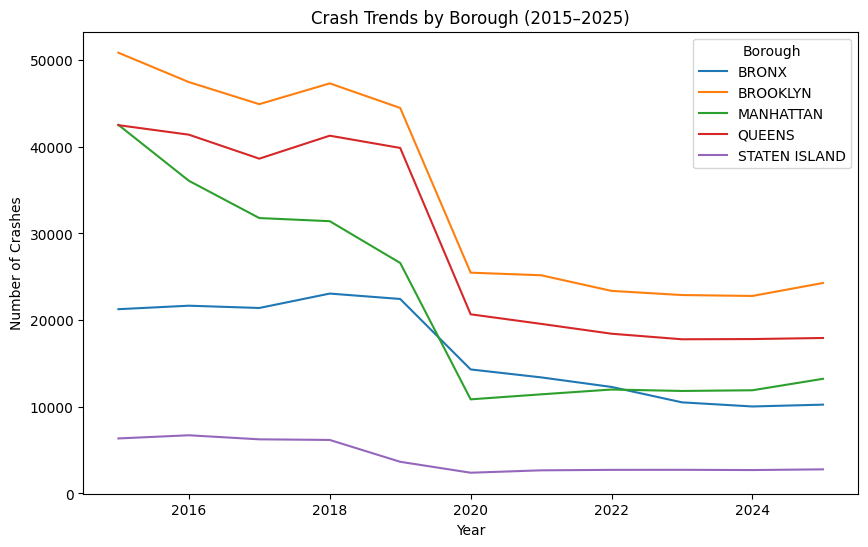

In [9]:
import matplotlib.pyplot as plt

crash_by_borough_year = (
    df_filtered
    .groupby(['YEAR', 'BOROUGH'])
    .size()
    .unstack()
)

ax = crash_by_borough_year.plot(figsize=(10,6))

ax.set_xlabel("Year")
ax.set_ylabel("Number of Crashes")
ax.set_title("Crash Trends by Borough (2015–2025)")

plt.legend(title="Borough")
plt.show()



---

##  Removal of Invalid and Non-informative Records

A filtering condition is applied to remove records where:

- borough, zip code, and street information are missing
- geographic coordinates are missing or equal to zero
- location information is unavailable

This step removes rows that contain insufficient information for spatial and analytical use.

The dataset shape is compared before and after removal to validate the impact of this cleaning step.

---

In [10]:
df_filtered['YEAR'].value_counts().sort_index()

YEAR
2015    217708
2016    229832
2017    231007
2018    231564
2019    211486
2020    112917
2021    110557
2022    103887
2023     96607
2024     91315
2025     85481
Name: count, dtype: int64

In [11]:
# Filter 2015–2025
df_2015_2025 = df_filtered[
    (df_filtered['YEAR'] >= 2015) &
    (df_filtered['YEAR'] <= 2025)
]

# Create pivot table (BOROUGH as rows, YEAR as columns)
borough_year_pivot = (
    df_2015_2025
    .pivot_table(
        index='BOROUGH',
        columns='YEAR',
        aggfunc='size',
        fill_value=0
    )
    .sort_index()
)

borough_year_pivot

YEAR,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
BOROUGH,,,,,,,,,,,
BRONX,21258,21660,21397,23060,22437,14306,13389,12285,10507,10033,10243
BROOKLYN,50851,47464,44915,47313,44479,25472,25173,23369,22890,22785,24281
MANHATTAN,42528,36077,31774,31412,26593,10855,11432,11988,11822,11903,13224
QUEENS,42493,41395,38627,41278,39865,20667,19564,18427,17786,17812,17934
STATEN ISLAND,6344,6709,6241,6171,3650,2388,2665,2718,2724,2697,2776


In [12]:
df_2015_2025.shape

(1722361, 30)

In [13]:
df_filtered.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           562255
ZIP CODE                          562533
LATITUDE                          160296
LONGITUDE                         160296
LOCATION                          160296
ON STREET NAME                    413350
CROSS STREET NAME                 779252
OFF STREET NAME                  1342190
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7245
CONTRIBUTING FACTOR VEHICLE 2     299033
CONTRIBUTING FACTOR VEHICLE 3    1594047
CONTRIBUTING FACTOR VEHICLE 4    1692237
CONTRIBUTING FACTOR VEHICLE 5    1713910
COLLISION_ID                           0
VEHICLE TYPE COD

In [14]:
df_filtered[[ 'LOCATION']].isnull().sum()

LOCATION    160296
dtype: int64

In [15]:
print("Shape before cleaning:", df_filtered.shape)

df_filtered = df_filtered.dropna(subset=['LONGITUDE', 'LOCATION'])

print("Shape after cleaning:", df_filtered.shape)

Shape before cleaning: (1722361, 30)
Shape after cleaning: (1562065, 30)


In [16]:
df_filtered[[ 'LOCATION']].isnull().sum()

LOCATION    0
dtype: int64

In [17]:
df_filtered.isnull().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           439752
ZIP CODE                          440004
LATITUDE                               0
LONGITUDE                              0
LOCATION                               0
ON STREET NAME                    386873
CROSS STREET NAME                 712634
OFF STREET NAME                  1197051
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       6749
CONTRIBUTING FACTOR VEHICLE 2     275855
CONTRIBUTING FACTOR VEHICLE 3    1446413
CONTRIBUTING FACTOR VEHICLE 4    1534643
CONTRIBUTING FACTOR VEHICLE 5    1554283
COLLISION_ID                           0
VEHICLE TYPE COD

In [18]:
train_df = df_filtered[df_filtered["BOROUGH"].notna()]
test_df = df_filtered[df_filtered["BOROUGH"].isna()]


## Handling Missing Borough Values Using Machine Learning

To recover missing borough information, a machine learning approach is applied.

Records are split into:
- a training set (rows with known boroughs)
- a test set (rows with missing boroughs)

Only geographic features are used:
- **Latitude**
- **Longitude**

A K-Nearest Neighbors (KNN) classifier is trained to learn spatial patterns and predict the borough for records with missing values.

The model is evaluated using a validation split and accuracy score to ensure reasonable prediction performance.

This approach allows:
- recovery of missing categorical information
- preservation of otherwise valuable crash records

---


In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

# Check missing BEFORE
print("Missing BOROUGH BEFORE:", df_filtered["BOROUGH"].isna().sum())

# Work on a copy to avoid warnings
df_ml = df_filtered.copy()

# Drop rows with missing coordinates
df_ml = df_ml.dropna(subset=["LATITUDE", "LONGITUDE"])

# Separate known / unknown borough
train_df = df_ml[df_ml["BOROUGH"].notna()].copy()
test_df = df_ml[df_ml["BOROUGH"].isna()].copy()

# Encode borough
le = LabelEncoder()
train_df["borough_encoded"] = le.fit_transform(train_df["BOROUGH"])

# Train model
X_train = train_df[["LATITUDE", "LONGITUDE"]]
y_train = train_df["borough_encoded"]

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predict missing borough
if len(test_df) > 0:
    X_test = test_df[["LATITUDE", "LONGITUDE"]]
    predicted = model.predict(X_test)

    test_df["BOROUGH"] = le.inverse_transform(predicted)

    # Update original df_filtered
    df_filtered.update(test_df)

# Check missing AFTER
print("Missing BOROUGH AFTER:", df_filtered["BOROUGH"].isna().sum())

Missing BOROUGH BEFORE: 439752
Missing BOROUGH AFTER: 0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = train_df[["LATITUDE", "LONGITUDE"]]
y = train_df["borough_encoded"]

X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_tr, y_tr)
val_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))

Validation Accuracy: 0.9956162040068964


---

## Duplicate Check

A final duplicate record check is performed to ensure no repeated rows remain in the cleaned dataset.

---


In [21]:
print("Total duplicate rows:", df_filtered.duplicated().sum())

Total duplicate rows: 0


---
## Removing the unnecessary column

---

In [22]:
print("Shape BEFORE:", df_filtered.shape)

Shape BEFORE: (1562065, 30)


In [23]:
columns_to_drop = [
    "ON STREET NAME",
    "OFF STREET NAME",
    "CROSS STREET NAME",
    "CONTRIBUTING FACTOR VEHICLE 4",
    "CONTRIBUTING FACTOR VEHICLE 5",
    "COLLISION_ID",  # use exact column name from your dataset
    "VEHICLE TYPE CODE 4",
    "VEHICLE TYPE CODE 5"
]

crash_data = df_filtered.drop(columns=columns_to_drop, errors='ignore').copy()

In [24]:
print("Shape AFTER:", crash_data.shape)

Shape AFTER: (1562065, 22)


In [25]:
crash_data["CRASH TIME"].unique()[:20]

array([datetime.time(1, 29), datetime.time(9, 35), datetime.time(8, 13),
       datetime.time(17, 5), datetime.time(8, 17), datetime.time(21, 10),
       datetime.time(14, 58), datetime.time(0, 34), datetime.time(16, 50),
       datetime.time(0, 59), datetime.time(23, 10), datetime.time(17, 58),
       datetime.time(20, 3), datetime.time(19, 43), datetime.time(14, 30),
       datetime.time(4, 45), datetime.time(5, 46), datetime.time(6, 30),
       datetime.time(3, 43), datetime.time(17, 40)], dtype=object)

In [26]:
crash_data["CRASH TIME"].head(10)

2     01:29:00
9     09:35:00
10    08:13:00
12    17:05:00
13    08:17:00
14    21:10:00
15    14:58:00
16    00:34:00
17    16:50:00
19    00:59:00
Name: CRASH TIME, dtype: object

1️⃣ Annual Crash Trend (NYC)

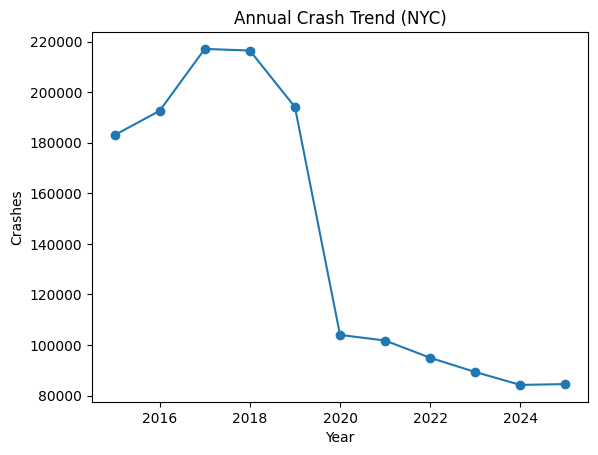

In [27]:
annual_crashes = crash_data.groupby(crash_data["CRASH DATE"].dt.year).size().sort_index()

plt.figure()
annual_crashes.plot(marker="o")
plt.title("Annual Crash Trend (NYC)")
plt.xlabel("Year")
plt.ylabel("Crashes")
plt.show()

2️⃣ Daily Crash Trend (NYC)

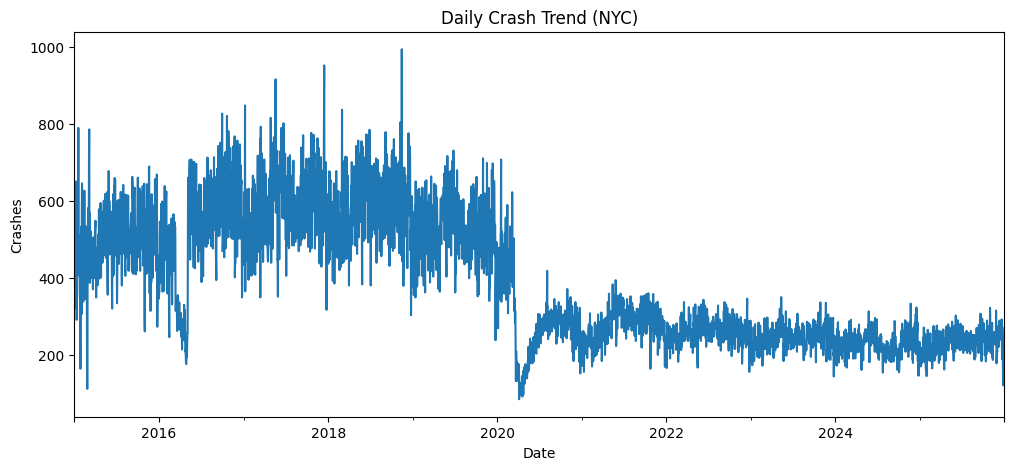

In [28]:
daily_total = crash_data.groupby("CRASH DATE").size().sort_index()

plt.figure(figsize=(12,5))
daily_total.plot()
plt.title("Daily Crash Trend (NYC)")
plt.xlabel("Date")
plt.ylabel("Crashes")
plt.show()

<Figure size 1200x500 with 0 Axes>

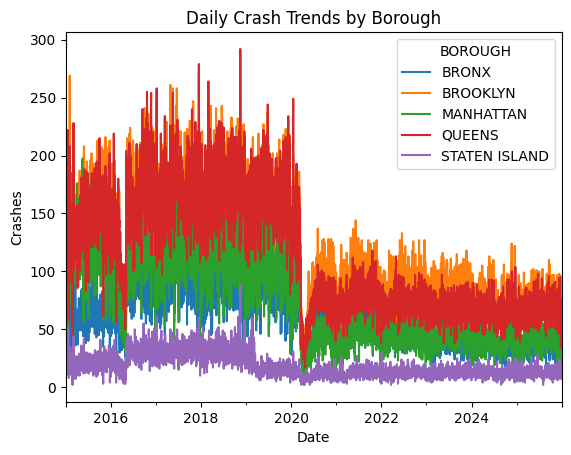

In [29]:
daily_borough = (
    crash_data.groupby(["CRASH DATE","BOROUGH"])
    .size()
    .unstack()
    .sort_index()
)

plt.figure(figsize=(12,5))
daily_borough.plot()
plt.title("Daily Crash Trends by Borough")
plt.xlabel("Date")
plt.ylabel("Crashes")
plt.show()

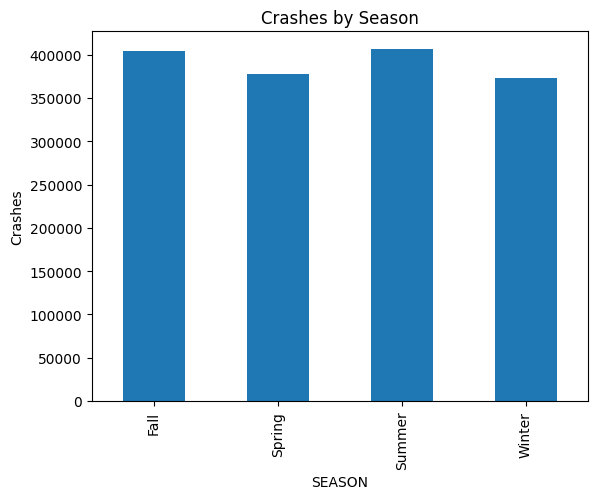

In [30]:
crash_data["MONTH"] = crash_data["CRASH DATE"].dt.month

def season(m):
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]: return "Spring"
    if m in [6,7,8]: return "Summer"
    return "Fall"

crash_data["SEASON"] = crash_data["MONTH"].apply(season)

season_counts = crash_data.groupby("SEASON").size()

plt.figure()
season_counts.plot(kind="bar")
plt.title("Crashes by Season")
plt.ylabel("Crashes")
plt.show()

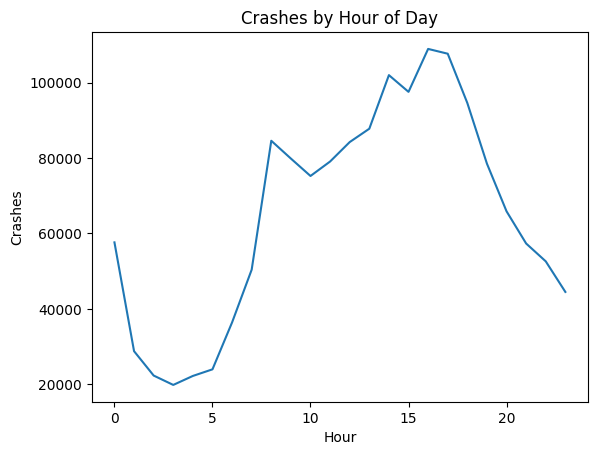

In [31]:
crash_data["HOUR"] = crash_data["CRASH TIME"].astype(str).str.slice(0,2)
crash_data["HOUR"] = pd.to_numeric(crash_data["HOUR"], errors="coerce")

hour_counts = crash_data.groupby("HOUR").size()

plt.figure()
hour_counts.plot()
plt.title("Crashes by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Crashes")
plt.show()

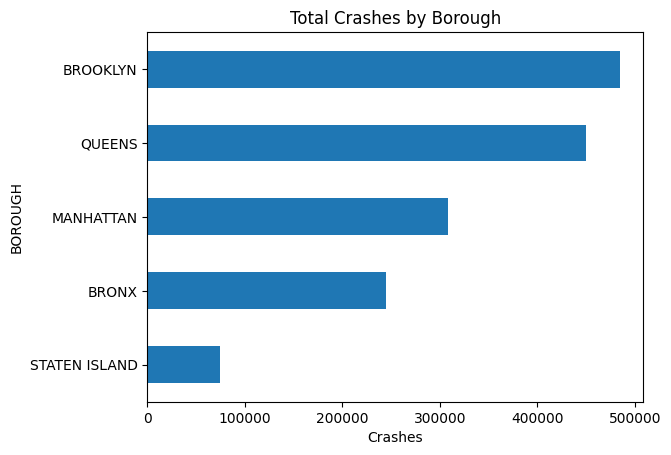

In [32]:
borough_totals = crash_data.groupby("BOROUGH").size().sort_values()

plt.figure()
borough_totals.plot(kind="barh")
plt.title("Total Crashes by Borough")
plt.xlabel("Crashes")
plt.show()

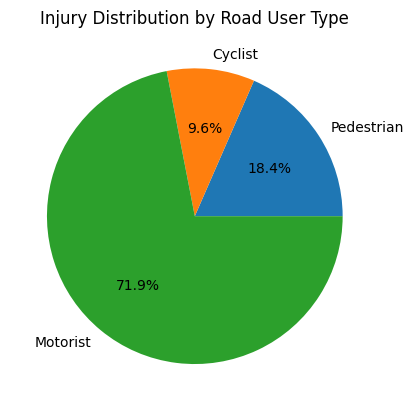

In [33]:
vru_totals = {
    "Pedestrian": crash_data["NUMBER OF PEDESTRIANS INJURED"].sum(),
    "Cyclist": crash_data["NUMBER OF CYCLIST INJURED"].sum(),
    "Motorist": crash_data["NUMBER OF MOTORIST INJURED"].sum()
}

plt.figure()
plt.pie(vru_totals.values(), labels=vru_totals.keys(), autopct="%1.1f%%")
plt.title("Injury Distribution by Road User Type")
plt.show()

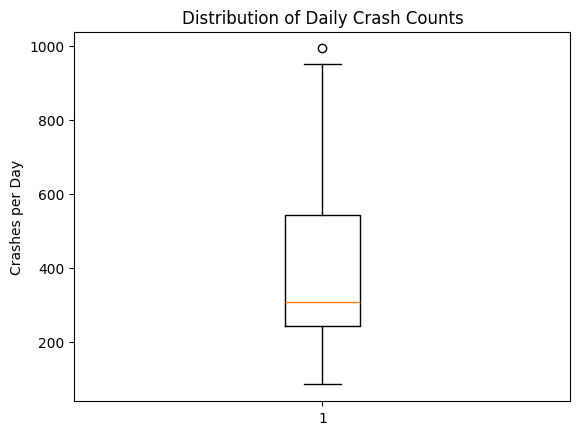

In [34]:
daily_total = crash_data.groupby("CRASH DATE").size()

plt.figure()
plt.boxplot(daily_total)
plt.title("Distribution of Daily Crash Counts")
plt.ylabel("Crashes per Day")
plt.show()

In [35]:
peak_day = daily_total.idxmax()
peak_value = daily_total.max()
low_day = daily_total.idxmin()
low_value = daily_total.min()

print("Peak crash day:", peak_day)
print("Crash count:", peak_value)

print("Lowest crash day:", low_day)
print("Crash count:", low_value)



Peak crash day: 2018-11-15 00:00:00
Crash count: 993
Lowest crash day: 2020-04-05 00:00:00
Crash count: 85


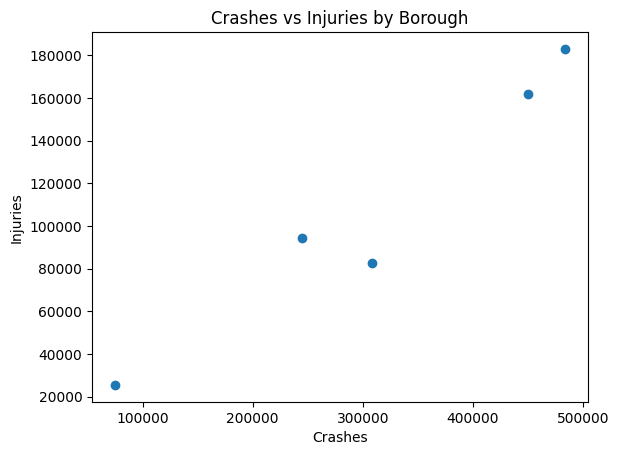

In [36]:
borough_stats = crash_data.groupby("BOROUGH").agg(
    crashes=("BOROUGH","count"),
    injuries=("NUMBER OF PERSONS INJURED","sum")
)

plt.figure()
plt.scatter(borough_stats["crashes"], borough_stats["injuries"])
plt.xlabel("Crashes")
plt.ylabel("Injuries")
plt.title("Crashes vs Injuries by Borough")
plt.show()

In [37]:
# Year / Month / Day / Weekday
crash_data["YEAR"] = crash_data["CRASH DATE"].dt.year
crash_data["MONTH"] = crash_data["CRASH DATE"].dt.month
crash_data["DAY"] = crash_data["CRASH DATE"].dt.day
crash_data["WEEKDAY"] = crash_data["CRASH DATE"].dt.weekday

# Weekend flag
crash_data["IS_WEEKEND"] = crash_data["WEEKDAY"].isin([5,6]).astype(int)

In [38]:
crash_data["HOUR"] = crash_data["CRASH TIME"].astype(str).str.slice(0,2)
crash_data["HOUR"] = pd.to_numeric(crash_data["HOUR"], errors="coerce")

In [39]:
def time_period(h):
    if 0 <= h <= 5: return "Night"
    if 6 <= h <= 9: return "Morning_Peak"
    if 10 <= h <= 15: return "Day"
    if 16 <= h <= 19: return "Evening_Peak"
    return "Late_Evening"

crash_data["TIME_PERIOD"] = crash_data["HOUR"].apply(time_period)

In [40]:
crash_data["RUSH_HOUR"] = crash_data["HOUR"].isin([7,8,9,16,17,18]).astype(int)

In [41]:
def season(m):
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]: return "Spring"
    if m in [6,7,8]: return "Summer"
    return "Fall"

crash_data["SEASON"] = crash_data["MONTH"].apply(season)

In [42]:
daily_counts = crash_data.groupby("CRASH DATE").size()
crash_data["DAILY_CRASH_LEVEL"] = crash_data["CRASH DATE"].map(daily_counts)

In [43]:
threshold = daily_counts.mean() + 2*daily_counts.std()
crash_data["PEAK_DAY"] = crash_data["CRASH DATE"].map(daily_counts > threshold).astype(int)

In [44]:
crash_data["INJURY_FLAG"] = (crash_data["NUMBER OF PERSONS INJURED"] > 0).astype(int)
crash_data["FATAL_FLAG"] = (crash_data["NUMBER OF PERSONS KILLED"] > 0).astype(int)

In [45]:
crash_data["PED_INJURY"] = (crash_data["NUMBER OF PEDESTRIANS INJURED"] > 0).astype(int)
crash_data["CYC_INJURY"] = (crash_data["NUMBER OF CYCLIST INJURED"] > 0).astype(int)
crash_data["MOT_INJURY"] = (crash_data["NUMBER OF MOTORIST INJURED"] > 0).astype(int)

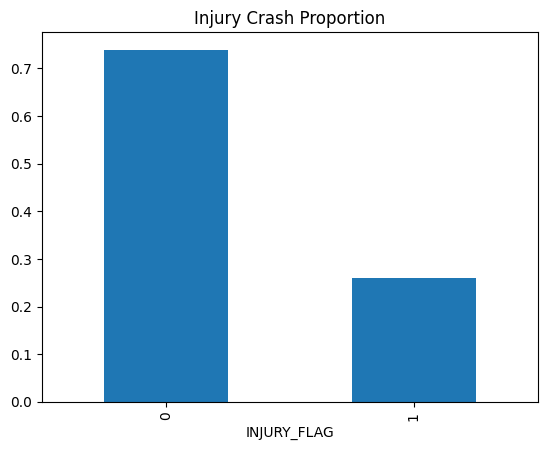

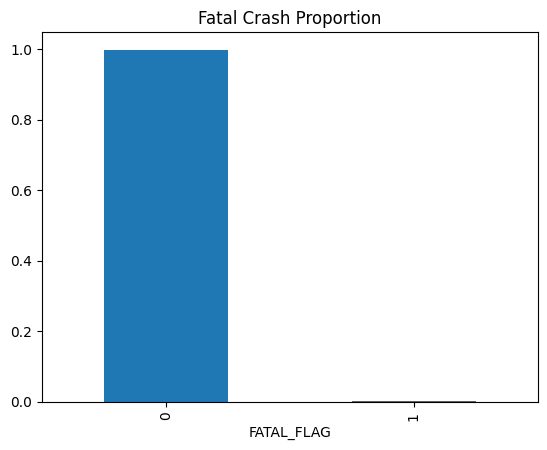

In [46]:
crash_data["INJURY_FLAG"].value_counts(normalize=True).plot(kind="bar")
plt.title("Injury Crash Proportion")
plt.show()

crash_data["FATAL_FLAG"].value_counts(normalize=True).plot(kind="bar")
plt.title("Fatal Crash Proportion")
plt.show()

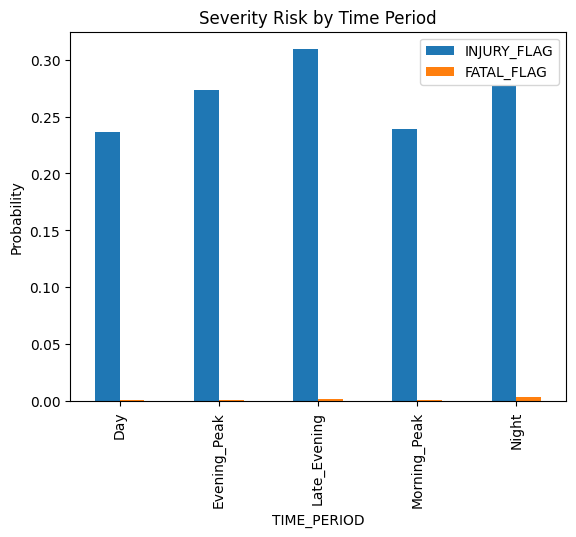

In [47]:
severity_time = crash_data.groupby("TIME_PERIOD")[["INJURY_FLAG","FATAL_FLAG"]].mean()

severity_time.plot(kind="bar")
plt.title("Severity Risk by Time Period")
plt.ylabel("Probability")
plt.show()

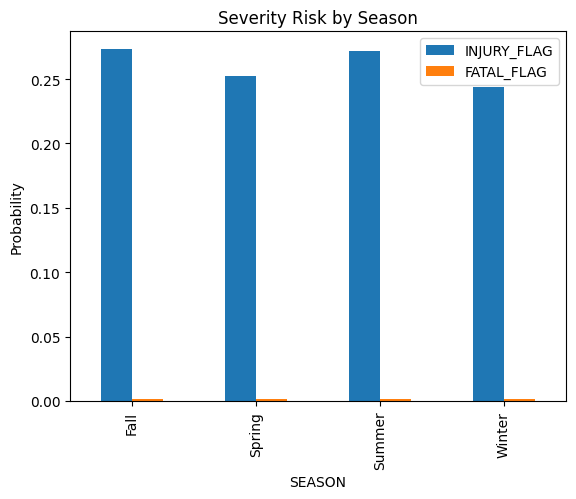

In [48]:
severity_season = crash_data.groupby("SEASON")[["INJURY_FLAG","FATAL_FLAG"]].mean()

severity_season.plot(kind="bar")
plt.title("Severity Risk by Season")
plt.ylabel("Probability")
plt.show()

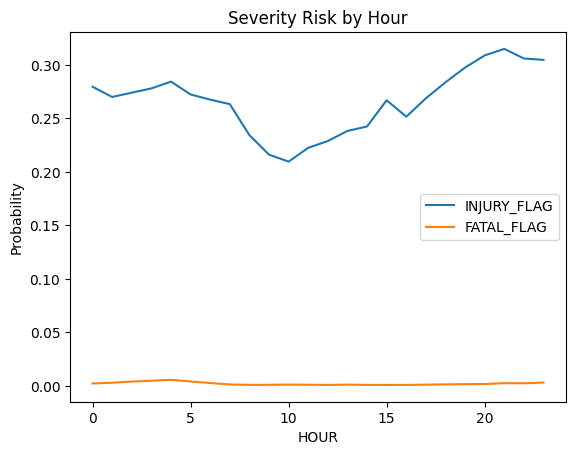

In [49]:
severity_hour = crash_data.groupby("HOUR")[["INJURY_FLAG","FATAL_FLAG"]].mean()

severity_hour.plot()
plt.title("Severity Risk by Hour")
plt.ylabel("Probability")
plt.show()